# <center>Machine Learning Project Code</center>

<a class="anchor" id="top"></a>

## <center>*02 - K-Fold*</center>

** **



# Table of Contents  <br>


1. [Importing Libraries & Data](#1.-Importing-Libraries-&-Data) <br><br>
    
2. [Cross Validation](#2.-Cross-Validation) <br><br>

3. [Final Predictions](#3.-Final-Predictions) <br><br>

** **

This notebook was created to compare the results from the hold-out validation used in the first notebook with the results obtained using K-Fold Cross-Validation.
We used the same cleaned dataset that was prepared in the first notebook to keep the comparison fair. then, for each model we applied the relevant preprocessing steps, including handling missing values and outliers.
By keeping the data and preprocessing unchanged, the goal was to see how the model results change when using K-Fold instead of hold-out validation.


** **

# 1. Importing Libraries & Data
In this section, we set up the foundation for our project by importing the necessary Python libraries and loading the dataset. These libraries provide the tools for data manipulation, visualization, and machine learning modeling throughout the notebook. Additionally, we import the historical claims dataset, which forms the core of our analysis.

In [8]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, TargetEncoder
import category_encoders as ce
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import matplotlib.pyplot as plt

In [9]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Load cleaned training data 
train = pd.read_csv('cleaned_train.csv')

# Load cleaned testing data
test = pd.read_csv('cleaned_test.csv')

# Display the first 3 rows of the training data
train.head(3)

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Other,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.0,0.0
1,53000,Toyota,Other,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.0,0.0
2,6366,Audi,Other,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.0,0.0


In [11]:
X = train.drop(['price', 'carID'], axis=1)
y = train['price']

In [12]:
X.shape

(75966, 12)

# 2. K-fold Validation


#### What We Decided to Do :

To make the evaluation fair and reliable, Here is our approach:

- **Put everything in one pipeline**  
  This avoids data leakage and keeps the process clean:

  - Handle missing values, outliers, scaling, and encoding as the same technique we used at the first notebook
  - Computes new features from raw columns for each fold’s training data
  - Keep only the 11 final features we selected earlier based on multiple selection methods in the first notebook.
  - Train the same used models in the first notebook

- **Stick to the same final feature set**  
  Original important columns + engineered features (`age`, `is_premium_brand`).

- **Drop useless columns**  
  For example, `hasDamage` was constant and removed.

- **Measure performance across folds**  
  Report **RMSE** and **R²** for each fold


## Preprocessing pipeline :

#### We would be creating these new  features (age, mileage_per_year, is_premium_brand,  performance_ratio) similarly in the holdout notebook:

In [13]:

class FeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self, reference_year=2025, 
                 premium_brands=('Audi', 'BMW', 'Mercedes', 'VW')):
        self.reference_year = reference_year
        self.premium_brands = premium_brands  

    def fit(self, X, y=None):
        self._premium_set = set(self.premium_brands or ())
        return self

    def transform(self, X):
        X2 = X.copy()

        # 1) age
        if 'year' in X2.columns and 'age' not in X2.columns:
            X2['age'] = self.reference_year - X2['year']

        # 2) mileage_per_year
        if {'mileage', 'age'}.issubset(X2.columns) and 'mileage_per_year' not in X2.columns:
            X2['mileage_per_year'] = X2['mileage'] / (X2['age'] + 1)

        # 3) is_premium_brand
        if 'Brand' in X2.columns and 'is_premium_brand' not in X2.columns:
            X2['is_premium_brand'] = X2['Brand'].isin(self._premium_set).astype(int)

        # 4) performance_ratio
        if {'engineSize', 'mpg'}.issubset(X2.columns) and 'performance_ratio' not in X2.columns:
            X2['performance_ratio'] = X2['engineSize'] / (X2['mpg'] + 1e-6)

        return X2


#### The final features utilised here are the selected final features from the feature selections methods in the Hold-out notebook

In [14]:
class ConsensusSelector(BaseEstimator, TransformerMixin):
    def __init__(self, keep_list):
        self.keep_list = keep_list
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[[c for c in self.keep_list if c in X.columns]]


final_features = [
    'model', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
    'engineSize', 'paintQuality%', 'previousOwners', 'age', 'is_premium_brand'
]


In [15]:
# Outlier capper for numerics
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=3):
        self.threshold = threshold
    def fit(self, X, y=None):
        self.means_ = np.nanmean(X, axis=0)
        self.stds_  = np.nanstd(X, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.means_ - self.threshold*self.stds_,
                          self.means_ + self.threshold*self.stds_)

# Identify numeric vs categorical among the FINAL features
num_cols = ['mileage','tax','mpg','engineSize','paintQuality%','previousOwners','age','is_premium_brand']
cat_cols = ['model','transmission','fuelType']


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capper',  OutlierCapper(threshold=3)),
    ('scaler',  RobustScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target',  ce.TargetEncoder())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


## Models pipelines 

###### For all subsequent models, we will apply all preprocessing steps inside the cross‑validation to avoid data leakage. This includes:
1. The engineering of new features (age, mileage_per_year, premium brand flag).
2. Utising the final features selected
3. Applying the  numerical and categorical preprocessing (imputation, outlier capping, scaling, target encoding)
4. Finally applying the respective models utilised in the holde out notebook.

### 2.1. Ridge Regression :

In [16]:
ridge_pipeline = Pipeline([
    ('feat_eng', FeatureEngineer(reference_year=2025, premium_brands=['Audi','BMW','Mercedes','VW'])),
    ('select'  , ConsensusSelector(keep_list=final_features)),
    ('prep'    , preprocessor),
    ('model'   , Ridge(alpha=1.0))
])

In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# RMSE
cv_mse  = -cross_val_score(ridge_pipeline, X, y, cv=kf, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(cv_mse)

# R²
cv_r2 = cross_val_score(ridge_pipeline, X, y, cv=kf, scoring='r2')

print("Ridge — 5-Fold CV")
print(f"RMSE per fold: {np.round(cv_rmse, 2)}")
print(f"Mean RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"R² per fold:  {np.round(cv_r2, 4)}")
print(f"Mean R²:      {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")


Ridge — 5-Fold CV
RMSE per fold: [5311.4  4999.46 5204.65 5173.68 5301.03]
Mean RMSE: 5198.04 ± 112.72
R² per fold:  [0.7085 0.7285 0.713  0.7181 0.7069]
Mean R²:      0.7150 ± 0.0078


### 2.2 MLP Regression :

#### We apply the optimized hyperparameters identified during the hold‑out evaluation, which include:
1. Hidden Layers-> (128, 128)
2. Activation-> relu
3. Solver-> adam
4. Learning Rate->0.002

In [18]:
# MLP pipeline (fixed (128,128) architecture) accoring to the first notebook

mlp_128x2_pipeline = Pipeline([
    ('feat_eng', FeatureEngineer(reference_year=2025, premium_brands=['Audi', 'BMW', 'Mercedes', 'VW'])),
    ('select',   ConsensusSelector(keep_list=final_features)),
    ('prep',     preprocessor),
    ('model',    MLPRegressor(
        hidden_layer_sizes=(128, 128),
        activation='relu',
        solver='adam',
        alpha=1e-3,
        learning_rate='adaptive',
        learning_rate_init=1e-3,
        max_iter=800,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    ))
])


kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_pipeline(name, pipe, X, y):
    # RMSE (via neg MSE)
    cv_mse  = -cross_val_score(pipe, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=None)
    cv_rmse = np.sqrt(cv_mse)
    # R^2
    cv_r2 = cross_val_score(pipe, X, y, cv=kf, scoring='r2', n_jobs=None)


    print(f"{name} — 5-Fold CV")
    print(f"RMSE per fold: {np.round(cv_rmse, 2)}")
    print(f"Mean RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
    print(f"R² per fold:  {np.round(cv_r2, 4)}")
    print(f"Mean R²:      {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print("-"*65)

evaluate_pipeline("MLP 128x2", mlp_128x2_pipeline, X, y)

MLP 128x2 — 5-Fold CV
RMSE per fold: [4482.53 4367.29 4496.85 4445.72 4490.48]
Mean RMSE: 4456.57 ± 48.03
R² per fold:  [0.7924 0.7928 0.7858 0.7918 0.7897]
Mean R²:      0.7905 ± 0.0026
-----------------------------------------------------------------


### 2.3 Decision Tree :

#### Similarly for the decision tree, we will be using the Max Depth = 5 which is the optimized depth identified during the hold‑out evaluation.

In [19]:

# Decision Tree: we choose max_depth=5 according to the first notebook
dt_depth5_pipeline = Pipeline([
    ('feat_eng', FeatureEngineer(reference_year=2025, premium_brands=['Audi', 'BMW', 'Mercedes', 'VW'])),
    ('select',   ConsensusSelector(keep_list=final_features)),
    ('prep',     preprocessor),  # kept for parity; tree does not require scaling but we keep it for fairness
    ('model',    DecisionTreeRegressor(max_depth=5, random_state=42))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_pipeline(name, pipe, X, y):
    """Print RMSE per fold, mean ± std, and R² per fold, mean ± std."""
    cv_mse  = -cross_val_score(pipe, X, y, cv=kf, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(cv_mse)
    cv_r2   =  cross_val_score(pipe, X, y, cv=kf, scoring='r2')

    print(f"{name} — 5-Fold CV")
    print(f"RMSE per fold: {np.round(cv_rmse, 2)}")
    print(f"Mean RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
    print(f"R² per fold:  {np.round(cv_r2, 4)}")
    print(f"Mean R²:      {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print("-"*70)
    
evaluate_pipeline("Decision Tree (depth=5)", dt_depth5_pipeline, X, y)

Decision Tree (depth=5) — 5-Fold CV
RMSE per fold: [4900.99 4745.55 4912.61 4790.14 4793.69]
Mean RMSE: 4828.60 ± 66.17
R² per fold:  [0.7518 0.7554 0.7443 0.7583 0.7603]
Mean R²:      0.7540 ± 0.0056
----------------------------------------------------------------------


### 2.4 KNN :


#### Similarly for the KNN, we will be using the K = 6 which is the best choice as identified during in the hold‑out evaluation.

In [20]:
knn_k6_pipeline = Pipeline([
    ('feat_eng', FeatureEngineer(reference_year=2025, premium_brands=['Audi','BMW','Mercedes','VW'])),
    ('select',   ConsensusSelector(keep_list=final_features)),
    ('prep',     preprocessor),   # scaling is important for KNN
    ('model',    KNeighborsRegressor(n_neighbors=6))
])



kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_pipeline(name, pipe, X, y):
    """
    Prints RMSE per fold, mean ± std, and R² per fold, mean ± std for a pipeline.
    """
    cv_mse  = -cross_val_score(pipe, X, y, cv=kf, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(cv_mse)
    cv_r2   =  cross_val_score(pipe, X, y, cv=kf, scoring='r2')

    print(f"{name} — 5-Fold CV")
    print(f"RMSE per fold: {np.round(cv_rmse, 2)}")
    print(f"Mean RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
    print(f"R² per fold:  {np.round(cv_r2, 4)}")
    print(f"Mean R²:      {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print("-"*72)
evaluate_pipeline("KNN (k=6)", knn_k6_pipeline, X, y)

KNN (k=6) — 5-Fold CV
RMSE per fold: [4117.27 4027.76 3941.01 3925.26 4113.84]
Mean RMSE: 4025.03 ± 81.75
R² per fold:  [0.8248 0.8238 0.8355 0.8377 0.8235]
Mean R²:      0.8291 ± 0.0062
------------------------------------------------------------------------


### 2.5 SVM :


#### We will apply the best parameters found (Manual Tuning) as identified in the hold out notebook
1. C-> 1000
2. Gamma-> auto
3. Epsilon-> 0.01
4. Kernel-> rbf

In [21]:

# SVR (RBF) Pipeline
svm_rbf_pipeline = Pipeline([
    ('feat_eng', FeatureEngineer(reference_year=2025,
                                 premium_brands=['Audi', 'BMW', 'Mercedes', 'VW'])),
    ('select',   ConsensusSelector(keep_list=final_features)),
    ('prep',     preprocessor),
    ('model',    SVR(
        kernel='rbf',
        C=1000,
        gamma='auto',   
        epsilon=0.01
    ))
])


kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_pipeline(name, pipe, X, y):
    """
    Prints RMSE per fold, mean ± std, and R² per fold, mean ± std for a pipeline.
    """
    cv_mse  = -cross_val_score(pipe, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(cv_mse)
    cv_r2   =  cross_val_score(pipe, X, y, cv=kf, scoring='r2', n_jobs=-1)

    print(f"{name} — 5-Fold CV")
    print(f"RMSE per fold: {np.round(cv_rmse, 2)}")
    print(f"Mean RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
    print(f"R² per fold:  {np.round(cv_r2, 4)}")
    print(f"Mean R²:      {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print("-"*72)

evaluate_pipeline("SVM (RBF)", svm_rbf_pipeline, X, y)


SVM (RBF) — 5-Fold CV
RMSE per fold: [4485.06 4235.37 4381.11 4345.54 4500.56]
Mean RMSE: 4389.53 ± 97.19
R² per fold:  [0.7921 0.8052 0.7967 0.8011 0.7887]
Mean R²:      0.7968 ± 0.0059
------------------------------------------------------------------------


# 3. Final Predictions

#### Comparison Table to show the Best model using K fold cross validation :

In [ ]:
# After we ran the whole models , we got the following results 

In [25]:
results = {
    'KNN (k=6)': {
        'rmse_per_fold': [4117.27, 4027.76, 3941.01, 3925.26, 4113.84],
        'mean_rmse': 4025.03,
        'std_rmse': 81.75,
        'r2_per_fold': [0.8248, 0.8238, 0.8355, 0.8377, 0.8235],
        'mean_r2': 0.8291,
        'std_r2': 0.0062,
    },
    'SVM (RBF)': {
        'rmse_per_fold': [4485.06, 4235.37, 4381.11, 4345.54, 4500.56],
        'mean_rmse': 4389.53,
        'std_rmse': 97.19,
        'r2_per_fold': [0.7921, 0.8052, 0.7967, 0.8011, 0.7887],
        'mean_r2': 0.7968,
        'std_r2': 0.0059,
    },
    'MLP 128x2': {
        'rmse_per_fold': [4482.53, 4367.29, 4496.85, 4445.72, 4490.48],
        'mean_rmse': 4456.57,
        'std_rmse': 48.03,
        'r2_per_fold': [0.7924, 0.7928, 0.7858, 0.7918, 0.7897],
        'mean_r2': 0.7905,
        'std_r2': 0.0026,
    },
    'Decision Tree (depth=5)': {
        'rmse_per_fold': [4900.99, 4745.55, 4912.61, 4790.14, 4793.69],
        'mean_rmse': 4828.60,
        'std_rmse': 66.17,
        'r2_per_fold': [0.7518, 0.7554, 0.7443, 0.7583, 0.7603],
        'mean_r2': 0.7540,
        'std_r2': 0.0056,
    },
    'Ridge': {
        'rmse_per_fold': [5311.40, 4999.46, 5204.65, 5173.68, 5301.03],
        'mean_rmse': 5198.04,
        'std_rmse': 112.72,
        'r2_per_fold': [0.7085, 0.7285, 0.7130, 0.7181, 0.7069],
        'mean_r2': 0.7150,
        'std_r2': 0.0078,
    },
}

# Build comparison table
rows = []
for model, m in results.items():
    rows.append({
        'Model': model,
        'Mean RMSE': m['mean_rmse'],
        'RMSE SD': m['std_rmse'],
        'Mean R^2': m['mean_r2'],
        'R^2 SD': m['std_r2'],
        'RMSE per fold': m['rmse_per_fold'],
        'R^2 per fold': m['r2_per_fold'],
    })

comp = pd.DataFrame(rows).set_index('Model')

# Rankings
comp['Rank RMSE'] = comp['Mean RMSE'].rank(method='min')         # lower is better
comp['Rank R^2']  = (-comp['Mean R^2']).rank(method='min')       # higher is better
comp['Avg Rank']  = (comp['Rank RMSE'] + comp['Rank R^2']) / 2

print("\n=== Cross-validated model comparison ===")
print(comp[['Mean RMSE','RMSE SD','Mean R^2','R^2 SD','Rank RMSE','Rank R^2','Avg Rank']]
      .sort_values(['Avg Rank','Mean RMSE']))

# Best models
best_rmse_model = comp['Mean RMSE'].idxmin()
best_r2_model   = comp['Mean R^2'].idxmax()

print(f"\nBest by RMSE: {best_rmse_model} ({comp.loc[best_rmse_model, 'Mean RMSE']:.2f})")
print(f"Best by R^2:  {best_r2_model} ({comp.loc[best_r2_model, 'Mean R^2']:.4f})")

# >>> summary <<<
top = comp.sort_values(['Avg Rank','Mean RMSE']).iloc[0]
overall_best = top.name
rmse_value = top['Mean RMSE']
r2_value = top['Mean R^2']

print(f"The overall strongest model under cross-validation is **{overall_best}**, "
      f"with the **lowest average RMSE** ({rmse_value:.2f}) and the **highest average R²** ({r2_value:.4f}).")
print("This indicates it delivers the most accurate predictions (lower error) "
      "and explains the largest proportion of variance among the evaluated models.")



=== Cross-validated model comparison ===
                         Mean RMSE  RMSE SD  Mean R^2  R^2 SD  Rank RMSE  \
Model                                                                      
KNN (k=6)                  4025.03    81.75    0.8291  0.0062        1.0   
SVM (RBF)                  4389.53    97.19    0.7968  0.0059        2.0   
MLP 128x2                  4456.57    48.03    0.7905  0.0026        3.0   
Decision Tree (depth=5)    4828.60    66.17    0.7540  0.0056        4.0   
Ridge                      5198.04   112.72    0.7150  0.0078        5.0   

                         Rank R^2  Avg Rank  
Model                                        
KNN (k=6)                     1.0       1.0  
SVM (RBF)                     2.0       2.0  
MLP 128x2                     3.0       3.0  
Decision Tree (depth=5)       4.0       4.0  
Ridge                         5.0       5.0  

Best by RMSE: KNN (k=6) (4025.03)
Best by R^2:  KNN (k=6) (0.8291)
The overall strongest model under c

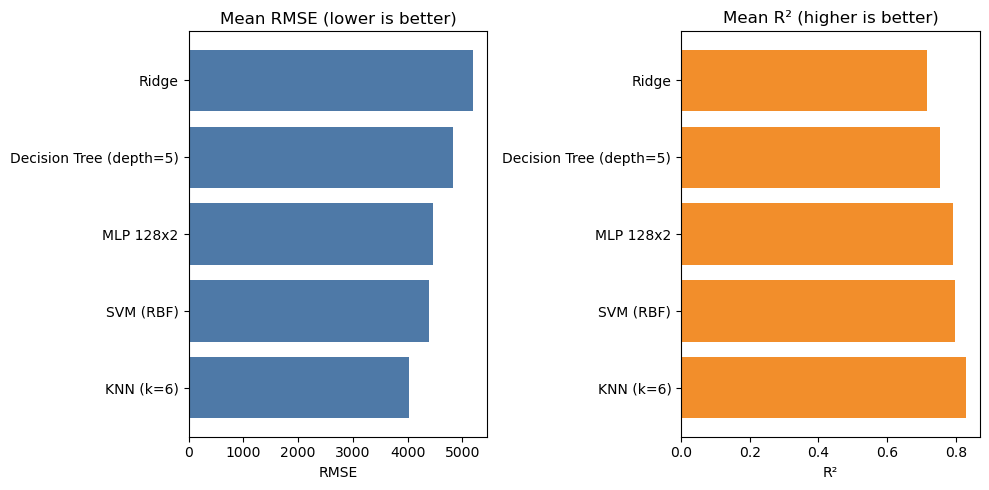

In [21]:
#  visualization

plt.figure(figsize=(10,5))
comp_sorted_rmse = comp.sort_values('Mean RMSE')
plt.subplot(1,2,1)
plt.barh(comp_sorted_rmse.index, comp_sorted_rmse['Mean RMSE'], color='#4e79a7')
plt.title('Mean RMSE (lower is better)')
plt.xlabel('RMSE')

comp_sorted_r2 = comp.sort_values('Mean R^2', ascending=False)
plt.subplot(1,2,2)
plt.barh(comp_sorted_r2.index, comp_sorted_r2['Mean R^2'], color='#f28e2b')
plt.title('Mean R² (higher is better)')
plt.xlabel('R²')

plt.tight_layout()
plt.savefig('model_cv_comparison.png', dpi=160, bbox_inches='tight')
comp.to_csv('model_cv_comparison.csv')

### Comparison Table: Identifying the Best Model Using Hold-Out Validation vs. K-Fold Cross-Validation :

#### Hold out method results from the previous notebook:

In [22]:

comparison_df = pd.DataFrame([
    {'Model': 'Ridge Regression', 'R² (Train)': 0.717042, 'R² (Validation)': 0.709063,
     'RMSE (Train)': 5309.872941, 'RMSE (Validation)': 5309.872941},
    {'Model': 'MLP', 'R² (Train)': 0.791748, 'R² (Validation)': 0.790375,
     'RMSE (Train)': 4427.083925, 'RMSE (Validation)': 4507.189502},
    {'Model': 'Decision Tree (max_depth=5)', 'R² (Train)': 0.763717, 'R² (Validation)': 0.755050,
     'RMSE (Train)': 4715.624146, 'RMSE (Validation)': 4872.183661},
    {'Model': 'KNN', 'R² (Train)': 0.875514, 'R² (Validation)': 0.814298,
     'RMSE (Train)': 3422.819952, 'RMSE (Validation)': 4242.219409},
    {'Model': 'SVM', 'R² (Train)': 0.875514, 'R² (Validation)': 0.814298,
     'RMSE (Train)': 4393.721254, 'RMSE (Validation)': 4611.333790},
])

comparison_df


,Model,R² (Train),R² (Validation),RMSE (Train),RMSE (Validation)
0,Ridge Regression,0.717042,0.709063,5309.872941,5309.872941
1,MLP,0.791748,0.790375,4427.083925,4507.189502
2,Decision Tree (max_depth=5),0.763717,0.755050,4715.624146,4872.183661
3,KNN,0.875514,0.814298,3422.819952,4242.219409
4,SVM,0.875514,0.814298,4393.721254,4611.333790


In [15]:
holdout = [
    {"Model": "Ridge", "R2_Train": 0.717042, "RMSE_Train": 5309.872941, "R2_Val": 0.709063, "RMSE_Val": 5309.872941},
    {"Model": "MLP", "R2_Train": 0.791748, "RMSE_Train": 4427.083925, "R2_Val": 0.790375, "RMSE_Val": 4507.189502},
    {"Model": "Decision Tree (depth=5)", "R2_Train": 0.763717, "RMSE_Train": 4715.624146, "R2_Val": 0.755050, "RMSE_Val": 4872.183661},
    {"Model": "KNN", "R2_Train": 0.875514, "RMSE_Train": 3422.819952, "R2_Val": 0.814298, "RMSE_Val": 4242.219409},
    {"Model": "SVM", "R2_Train": 0.875514, "RMSE_Train": 4393.721254, "R2_Val": 0.814298, "RMSE_Val": 4611.333790},
]
cv = [
    {"Model": "KNN", "CV_R2": 0.8291, "CV_RMSE": 4025.03, "CV_RMSE_SD": 81.75, "CV_R2_SD": 0.0062},
    {"Model": "SVM", "CV_R2": 0.7968, "CV_RMSE": 4398.53, "CV_RMSE_SD": 97.19, "CV_R2_SD": 0.0059},
    {"Model": "MLP", "CV_R2": 0.7905, "CV_RMSE": 4456.57, "CV_RMSE_SD": 48.03, "CV_R2_SD": 0.0066},
    {"Model": "Decision Tree (depth=5)", "CV_R2": 0.7504, "CV_RMSE": 4828.60, "CV_RMSE_SD": 112.72, "CV_R2_SD": 0.0075},
    {"Model": "Ridge", "CV_R2": 0.7150, "CV_RMSE": 5198.04, "CV_RMSE_SD": 112.72, "CV_R2_SD": 0.0078},
]

holdout_df = pd.DataFrame(holdout)
cv_df = pd.DataFrame(cv)


final_df = holdout_df.merge(cv_df, on="Model", how="outer")

final_df = final_df[[
    "Model",
    "R2_Train", "RMSE_Train",
    "R2_Val", "RMSE_Val",
    "CV_R2", "CV_RMSE", "CV_RMSE_SD", "CV_R2_SD"
]].sort_values(["CV_RMSE", "RMSE_Val"]).reset_index(drop=True)

print(final_df.to_markdown(index=False, floatfmt=".4f"))



| Model                   |   R2_Train |   RMSE_Train |   R2_Val |   RMSE_Val |   CV_R2 |   CV_RMSE |   CV_RMSE_SD |   CV_R2_SD |
|:------------------------|-----------:|-------------:|---------:|-----------:|--------:|----------:|-------------:|-----------:|
| KNN                     |     0.8755 |    3422.8200 |   0.8143 |  4242.2194 |  0.8291 | 4025.0300 |      81.7500 |     0.0062 |
| SVM                     |     0.8755 |    4393.7213 |   0.8143 |  4611.3338 |  0.7968 | 4398.5300 |      97.1900 |     0.0059 |
| MLP                     |     0.7917 |    4427.0839 |   0.7904 |  4507.1895 |  0.7905 | 4456.5700 |      48.0300 |     0.0066 |
| Decision Tree (depth=5) |     0.7637 |    4715.6241 |   0.7550 |  4872.1837 |  0.7504 | 4828.6000 |     112.7200 |     0.0075 |
| Ridge                   |     0.7170 |    5309.8729 |   0.7091 |  5309.8729 |  0.7150 | 5198.0400 |     112.7200 |     0.0078 |


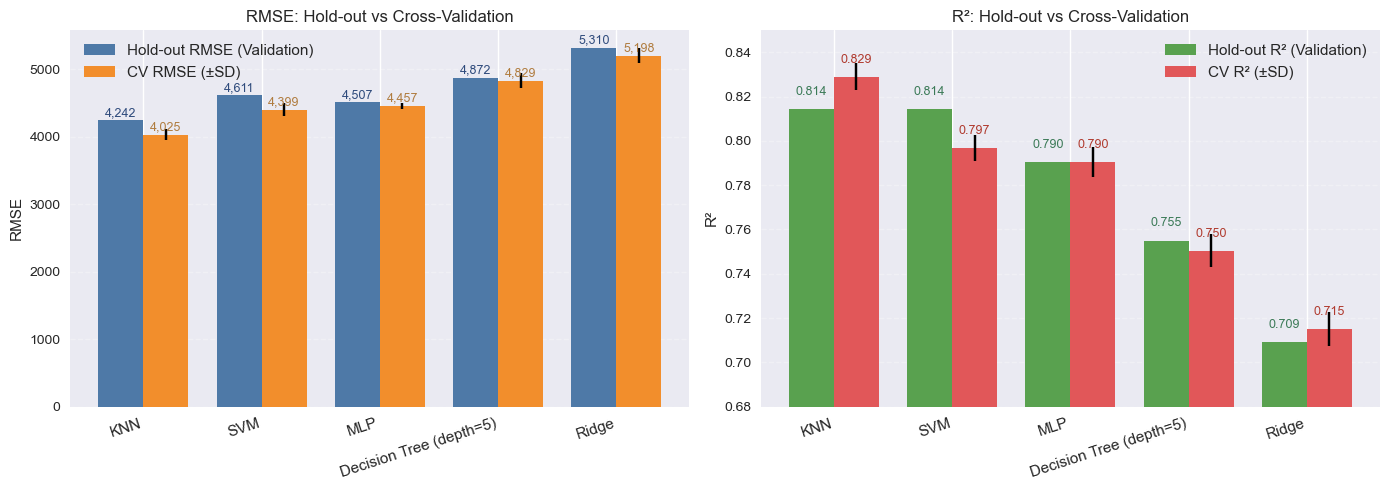

In [18]:
models = ["KNN", "SVM", "MLP", "Decision Tree (depth=5)", "Ridge"]

# Hold-out (Validation)
R2_Val = [0.8143, 0.8143, 0.7904, 0.7550, 0.7091]
RMSE_Val = [4242.2194, 4611.3338, 4507.1895, 4872.1837, 5309.8729]

# Cross-Validation (means + standard deviations)
CV_R2       = [0.8291, 0.7968, 0.7905, 0.7504, 0.7150]
CV_R2_SD    = [0.0062, 0.0059, 0.0066, 0.0075, 0.0078]
CV_RMSE     = [4025.03, 4398.53, 4456.57, 4828.60, 5198.04]
CV_RMSE_SD  = [81.75,   97.19,   48.03,   112.72,  112.72]

plt.style.use("seaborn-v0_8")
x = np.arange(len(models))
width = 0.38  # bar width
fontsize = 11

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width/2, RMSE_Val, width,
            label="Hold-out RMSE (Validation)", color="#4e79a7")
axes[0].bar(x + width/2, CV_RMSE, width,
            yerr=CV_RMSE_SD, capsize=4,
            label="CV RMSE (±SD)", color="#f28e2c")

axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=18, ha="right", fontsize=fontsize)
axes[0].set_ylabel("RMSE", fontsize=fontsize)
axes[0].set_title("RMSE: Hold-out vs Cross-Validation", fontsize=fontsize+1)
axes[0].grid(axis="y", linestyle="--", alpha=0.3)
axes[0].legend(fontsize=fontsize)

# Optional: annotate bars with values
for i, v in enumerate(RMSE_Val):
    axes[0].text(i - width/2, v + 25, f"{v:,.0f}", ha="center", va="bottom", fontsize=9, color="#2f4b7c")
for i, v in enumerate(CV_RMSE):
    axes[0].text(i + width/2, v + 25, f"{v:,.0f}", ha="center", va="bottom", fontsize=9, color="#b07c3f")

axes[1].bar(x - width/2, R2_Val, width,
            label="Hold-out R² (Validation)", color="#59a14f")
axes[1].bar(x + width/2, CV_R2, width,
            yerr=CV_R2_SD, capsize=4,
            label="CV R² (±SD)", color="#e15759")

axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=18, ha="right", fontsize=fontsize)
axes[1].set_ylabel("R²", fontsize=fontsize)
axes[1].set_ylim(0.68, 0.85)  # zoom to make differences clearer
axes[1].set_title("R²: Hold-out vs Cross-Validation", fontsize=fontsize+1)
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
axes[1].legend(fontsize=fontsize)

# Optional: annotate bars with values
for i, v in enumerate(R2_Val):
    axes[1].text(i - width/2, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=9, color="#3b7a57")
for i, v in enumerate(CV_R2):
    axes[1].text(i + width/2, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=9, color="#b03a2e")

fig.tight_layout()
plt.savefig("comparison_holdout_vs_cv.png", dpi=300, bbox_inches="tight")
plt.show()


In Hold out method , MLP was chosen as the best model because it provided the most balanced trade-off between accuracy and generalization (small train–validation gap, good R², and RMSE).
However, Cross-Validation tells a different story:

KNN achieved the best average performance across folds (lowest RMSE and highest R²), but it showed higher variance and a bigger gap between training and validation in Hold-out, which raises concerns about robustness on unseen data.
MLP, while slightly behind KNN in raw CV metrics, remained very stable and had minimal overfitting in Hold-out, making it a strong candidate for real-world deployment where consistency matters.

## Final Thoughts
- **Hold-out Priority:** MLP is the best choice for unseen data due to minimal overfitting and strong generalization.
- **Cross-Validation Priority:** KNN shows top accuracy and consistency across folds.
- **Recommendation:**  
  - For **robustness and stability** → **MLP**  
  - For **maximum predictive accuracy** → **KNN**